In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv("../data/processed/feature_engineered_credit_data.csv")

In [2]:
X = df.drop(columns=["Default"])

y = df["Default"]

print(X.shape)
print(y.shape)


(30000, 68)
(30000,)


In [3]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)
print(y_train.value_counts(normalize=True))

print()

print(y_test.value_counts(normalize=True))



Default
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Default
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)

    # Probability (needed for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2)

    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "F2": f2,
        "ROC-AUC": roc
    }

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [6]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_results = evaluate_model(
    lr,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)

lr_results

{'Accuracy': 0.8135,
 'Precision': 0.6661341853035144,
 'Recall': 0.3142426525998493,
 'F1': 0.4270353302611367,
 'F2': 0.35136501516683516,
 'ROC-AUC': 0.7508652940758137}

In [7]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt_results = evaluate_model(
    dt,
    X_train,
    y_train,
    X_test,
    y_test
)

dt_results

{'Accuracy': 0.7213333333333334,
 'Precision': 0.3763440860215054,
 'Recall': 0.39562923888470236,
 'F1': 0.3857457751653196,
 'F2': 0.39161569446516487,
 'ROC-AUC': 0.6051404668645142}

In [8]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    n_jobs=-1
)

rf_results = evaluate_model(
    rf,
    X_train,
    y_train,
    X_test,
    y_test
)

rf_results

{'Accuracy': 0.8105,
 'Precision': 0.6233766233766234,
 'Recall': 0.3617181612660136,
 'F1': 0.45779685264663805,
 'F2': 0.39486673247778875,
 'ROC-AUC': 0.76321098403808}

In [9]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_results = evaluate_model(
    xgb,
    X_train,
    y_train,
    X_test,
    y_test
)

xgb_results

{'Accuracy': 0.8078333333333333,
 'Precision': 0.6126943005181347,
 'Recall': 0.35644310474755087,
 'F1': 0.4506908051453073,
 'F2': 0.38898026315789475,
 'ROC-AUC': 0.7542576919374089}

In [10]:
lgbm = LGBMClassifier(
    random_state=42
)

lgbm_results = evaluate_model(
    lgbm,
    X_train,
    y_train,
    X_test,
    y_test
)

lgbm_results

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005013 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13088
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639


{'Accuracy': 0.815,
 'Precision': 0.6456375838926175,
 'Recall': 0.3624717407686511,
 'F1': 0.4642857142857143,
 'F2': 0.39732364116966795,
 'ROC-AUC': 0.7778676457663523}

In [11]:
results = pd.DataFrame({
    "Logistic Regression": lr_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results,
    "LightGBM": lgbm_results
}).T

results.sort_values("F2", ascending=False)

,Accuracy,Precision,Recall,F1,F2,ROC-AUC
LightGBM,0.815000,0.645638,0.362472,0.464286,0.397324,0.777868
Random Forest,0.810500,0.623377,0.361718,0.457797,0.394867,0.763211
Decision Tree,0.721333,0.376344,0.395629,0.385746,0.391616,0.605140
XGBoost,0.807833,0.612694,0.356443,0.450691,0.388980,0.754258
Logistic Regression,0.813500,0.666134,0.314243,0.427035,0.351365,0.750865


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score
)

def evaluate_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "F2": fbeta_score(y_test, y_pred, beta=2),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return metrics

In [13]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())


Before SMOTE
Default
0    18691
1     5309
Name: count, dtype: int64

After SMOTE
Default
0    18691
1    18691
Name: count, dtype: int64


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)



In [15]:
lr_results = evaluate_model(
    lr,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)
dt_results = evaluate_model(
    dt,
    X_train,
    y_train,
    X_test,
    y_test
)
rf_results = evaluate_model(
    rf,
    X_train,
    y_train,
    X_test,
    y_test
)
xgb_results = evaluate_model(
    xgb,
    X_train,
    y_train,
    X_test,
    y_test
)
lgbm_results = evaluate_model(
    lgbm,
    X_train,
    y_train,
    X_test,
    y_test
)


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005155 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13088
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639


In [16]:
rf_smote = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    n_jobs=-1
)

rf_smote_results = evaluate_model(
    rf_smote,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test
)

xgb_smote = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_smote_results = evaluate_model(
    xgb_smote,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test
)

lgbm_smote = LGBMClassifier(
    random_state=42
)

lgbm_smote_results = evaluate_model(
    lgbm_smote,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test
)



[LightGBM] [Info] Number of positive: 18691, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007772 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13684
[LightGBM] [Info] Number of data points in the train set: 37382, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [17]:
baseline_results = pd.DataFrame({
    "Logistic Regression": lr_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results,
    "LightGBM": lgbm_results
}).T

baseline_results

,Accuracy,Precision,Recall,F1,F2,ROC-AUC
Logistic Regression,0.809500,0.707207,0.236624,0.354602,0.272949,0.750207
Decision Tree,0.721333,0.376344,0.395629,0.385746,0.391616,0.605140
Random Forest,0.810500,0.623377,0.361718,0.457797,0.394867,0.763211
XGBoost,0.807833,0.612694,0.356443,0.450691,0.388980,0.754258
LightGBM,0.815000,0.645638,0.362472,0.464286,0.397324,0.777868


In [18]:
smote_results = pd.DataFrame({
    "Random Forest": rf_smote_results,
    "XGBoost": xgb_smote_results,
    "LightGBM": lgbm_smote_results
}).T

smote_results

,Accuracy,Precision,Recall,F1,F2,ROC-AUC
Random Forest,0.801000,0.561404,0.458176,0.504564,0.475669,0.756940
XGBoost,0.790667,0.533085,0.431047,0.476667,0.448206,0.753117
LightGBM,0.801667,0.565425,0.446119,0.498736,0.465775,0.771463


In [19]:
comparison = pd.DataFrame({
    "RF Before": rf_results,
    "RF After": rf_smote_results,
    "XGB Before": xgb_results,
    "XGB After": xgb_smote_results,
    "LGBM Before": lgbm_results,
    "LGBM After": lgbm_smote_results
})

comparison

,RF Before,RF After,XGB Before,XGB After,LGBM Before,LGBM After
Accuracy,0.810500,0.801000,0.807833,0.790667,0.815000,0.801667
Precision,0.623377,0.561404,0.612694,0.533085,0.645638,0.565425
Recall,0.361718,0.458176,0.356443,0.431047,0.362472,0.446119
F1,0.457797,0.504564,0.450691,0.476667,0.464286,0.498736
F2,0.394867,0.475669,0.388980,0.448206,0.397324,0.465775
ROC-AUC,0.763211,0.756940,0.754258,0.753117,0.777868,0.771463


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_train, y_train, X_test, y_test, threshold=0.5):

    model.fit(X_train, y_train)

    # Probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Apply threshold
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "F2": fbeta_score(y_test, y_pred, beta=2),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return metrics, y_pred, y_prob

In [21]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_metrics, rf_pred, rf_prob = evaluate_model(
    rf_smote,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test,
    threshold=0.5
)

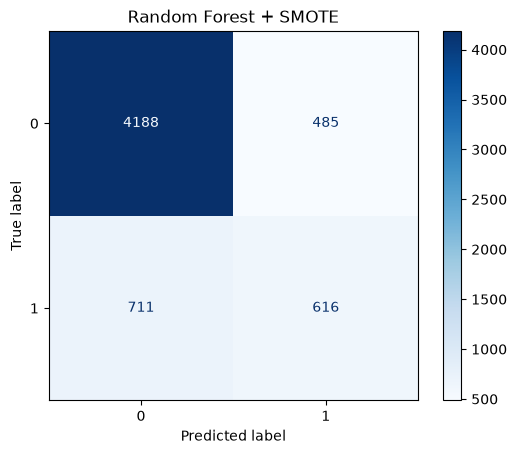

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Blues"
)

plt.title("Random Forest + SMOTE")
plt.show()

In [23]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      4673
           1       0.56      0.46      0.51      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.68      0.69      6000
weighted avg       0.79      0.80      0.79      6000



In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score
)

threshold_results = []

for threshold in np.arange(0.1, 0.91, 0.05):

    y_pred = (rf_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "F2": fbeta_score(y_test, y_pred, beta=2)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df


,Threshold,Accuracy,Precision,Recall,F1,F2
0,0.10,0.388500,0.257356,0.935946,0.403706,0.612789
1,0.15,0.498333,0.288089,0.862095,0.431861,0.616446
2,0.20,0.583000,0.321048,0.794273,0.457267,0.613433
3,0.25,0.659500,0.365312,0.731726,0.487327,0.609465
4,0.30,0.714000,0.409324,0.661643,0.505760,0.589025
5,0.35,0.748167,0.447846,0.595328,0.511161,0.558541
6,0.40,0.774167,0.490591,0.550113,0.518650,0.537081
7,0.45,0.791833,0.531002,0.503391,0.516828,0.508681
8,0.50,0.801000,0.561404,0.458176,0.504564,0.475669
9,0.55,0.807333,0.595531,0.401658,0.479748,0.429631


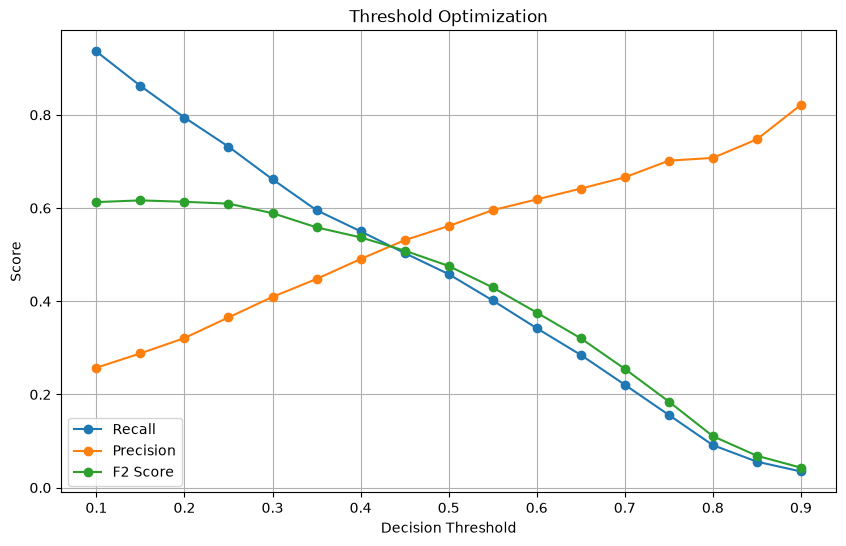

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["F2"], marker="o", label="F2 Score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()
plt.grid(True)

plt.show()

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_smote.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
59,ON_TIME_COUNT,0.099686
53,AVG_DELAY,0.080225
56,DELAY_STD,0.049936
54,MAX_DELAY,0.033782
57,LATE_PAYMENT_COUNT,0.027980
5,PAY_0,0.022599
4,AGE,0.022052
0,LIMIT_BAL,0.020605
58,SERIOUS_DELAY_COUNT,0.015050
64,RECENT_AVG_PAYMENT,0.014719


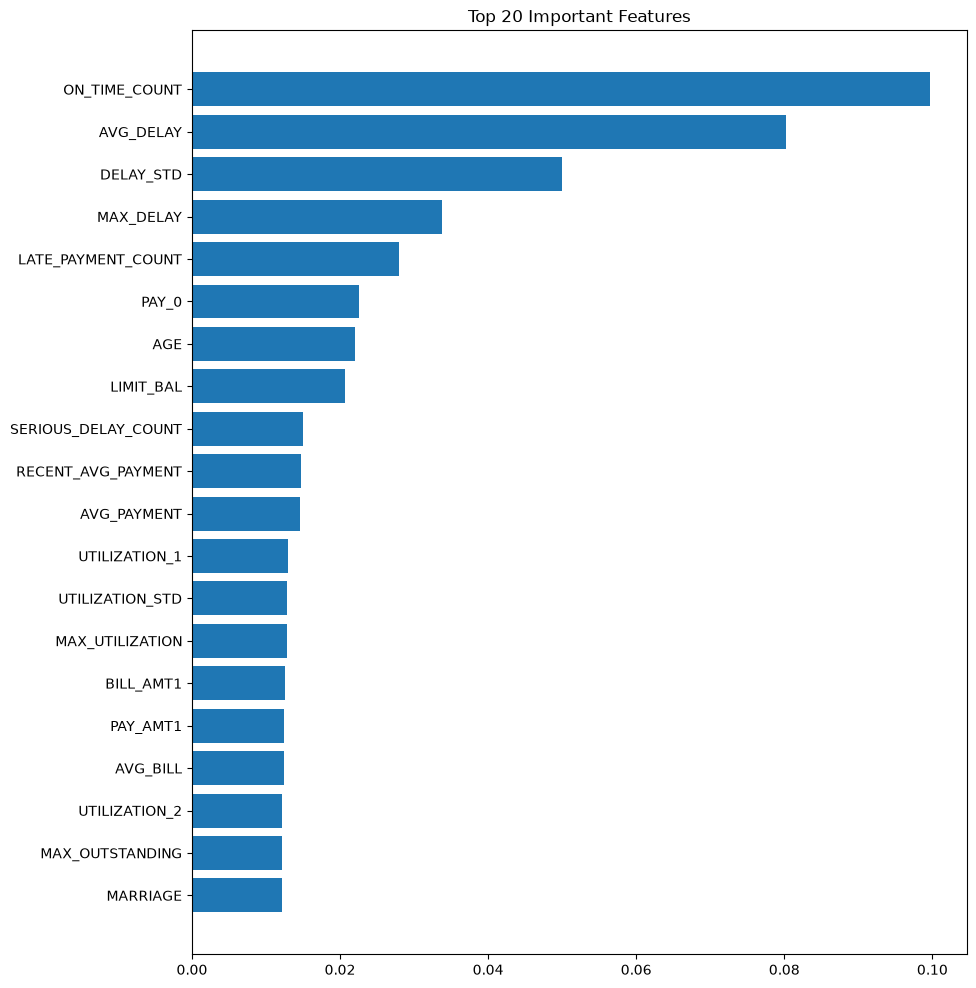

In [27]:
plt.figure(figsize=(10,12))

top_features = feature_importance.head(20)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [28]:
feature_importance.tail(20)

,Feature,Importance
15,BILL_AMT5,0.009649
46,OUTSTANDING_2,0.009620
37,PAY_RATIO_5,0.009607
22,PAY_AMT6,0.009607
47,OUTSTANDING_3,0.009535
12,BILL_AMT2,0.009470
14,BILL_AMT4,0.009427
50,OUTSTANDING_6,0.009350
13,BILL_AMT3,0.009293
20,PAY_AMT4,0.009261


In [29]:
corr = df.corr(numeric_only=True).abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = []

for column in upper.columns:
    for row in upper.index:
        if upper.loc[row, column] > 0.90:
            high_corr.append(
                (row, column, upper.loc[row, column])
            )

high_corr

[('BILL_AMT1', 'BILL_AMT2', np.float64(0.9514836727518136)),
 ('BILL_AMT2', 'BILL_AMT3', np.float64(0.9283262592714855)),
 ('BILL_AMT3', 'BILL_AMT4', np.float64(0.9239694565909823)),
 ('BILL_AMT4', 'BILL_AMT5', np.float64(0.9401344040880004)),
 ('BILL_AMT4', 'BILL_AMT6', np.float64(0.9009409547978421)),
 ('BILL_AMT5', 'BILL_AMT6', np.float64(0.9461968070521957)),
 ('UTILIZATION_1', 'UTILIZATION_2', np.float64(0.9340317412579465)),
 ('UTILIZATION_2', 'UTILIZATION_3', np.float64(0.9077145145037506)),
 ('UTILIZATION_4', 'UTILIZATION_5', np.float64(0.9055703633232144)),
 ('UTILIZATION_5', 'UTILIZATION_6', np.float64(0.9169781737954007)),
 ('UTILIZATION_1', 'AVG_UTILIZATION', np.float64(0.9123589266932756)),
 ('UTILIZATION_2', 'AVG_UTILIZATION', np.float64(0.940756362521736)),
 ('UTILIZATION_3', 'AVG_UTILIZATION', np.float64(0.9495082935255429)),
 ('UTILIZATION_4', 'AVG_UTILIZATION', np.float64(0.9481036871502261)),
 ('UTILIZATION_5', 'AVG_UTILIZATION', np.float64(0.9229785214548318)),
 ('U

In [30]:
features_to_drop = [

    # duplicate financial ratio
    "AVG_BILL_TO_LIMIT",

    # redundant repayment feature
    "ON_TIME_COUNT",

    # monthly bill amounts
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",

    # monthly utilization
    "UTILIZATION_1",
    "UTILIZATION_2",
    "UTILIZATION_3",
    "UTILIZATION_4",
    "UTILIZATION_5",
    "UTILIZATION_6"
]

In [31]:
df_pruned = df.drop(columns=features_to_drop)

In [32]:
X = df_pruned.drop(columns=["Default"])
y = df_pruned["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_train, y_train, X_test, y_test, threshold=0.5):

    # Train
    model.fit(X_train, y_train)

    # Probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Apply threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "F2": fbeta_score(y_test, y_pred, beta=2),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return metrics

In [40]:
X_train_smote.shape

(37382, 54)

In [35]:
rf_final = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    n_jobs=-1
)

final_results = evaluate_model(
    rf_final,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test
)

final_results

{'Accuracy': 0.802,
 'Precision': 0.5627822944896116,
 'Recall': 0.4694800301431801,
 'F1': 0.5119145439605588,
 'F2': 0.48558067030397506,
 'ROC-AUC': 0.7562246102326519}

In [36]:
comparisons = pd.DataFrame({
    "Before Feature Selection": rf_smote_results,
    "After Feature Selection": final_results
})

comparisons

,Before Feature Selection,After Feature Selection
Accuracy,0.801000,0.802000
Precision,0.561404,0.562782
Recall,0.458176,0.469480
F1,0.504564,0.511915
F2,0.475669,0.485581
ROC-AUC,0.756940,0.756225
